In [1]:
# pip install scikit-learn pandas numpy matplotlib seaborn joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
#Load data (California or your CSV)
"""Option A (default): California Housing (built‑in; all numeric).

Option B: Your own CSV — set USE_CALIFORNIA=False, CSV_PATH, and TARGET."""
USE_CALIFORNIA = True
CSV_PATH = 'my_housing.csv'    # used if USE_CALIFORNIA=False
TARGET   = 'SalePrice'

In [2]:
import pandas as pd

# Load the California Housing dataset
# Using the version that includes the 'ocean_proximity' categorical feature
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# 1. Print the shape of the dataset (rows, columns)
print(f"Shape of the dataset: {df.shape}")

# 2. Preview the first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# 3. Identify Numeric vs Categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

# 4. Print the lists
print(f"\nNumeric Columns ({len(numeric_cols)}):")
print(numeric_cols)

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)


Shape of the dataset: (20640, 10)

First 5 rows of the dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Numeric Co

In [ ]:
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Configure visual settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the dataset
housing_data = fetch_california_housing()
df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

# Add the target variable (Median House Value) to the dataframe
# Note: The target is expressed in hundreds of thousands of dollars ($100,000)
df['MedHouseVal'] = housing_data.target

# 2. Initial Inspection
print("--- Dataset Info ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Statistical Summary ---")
print(df.describe())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

--- First 5 Rows ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.0730

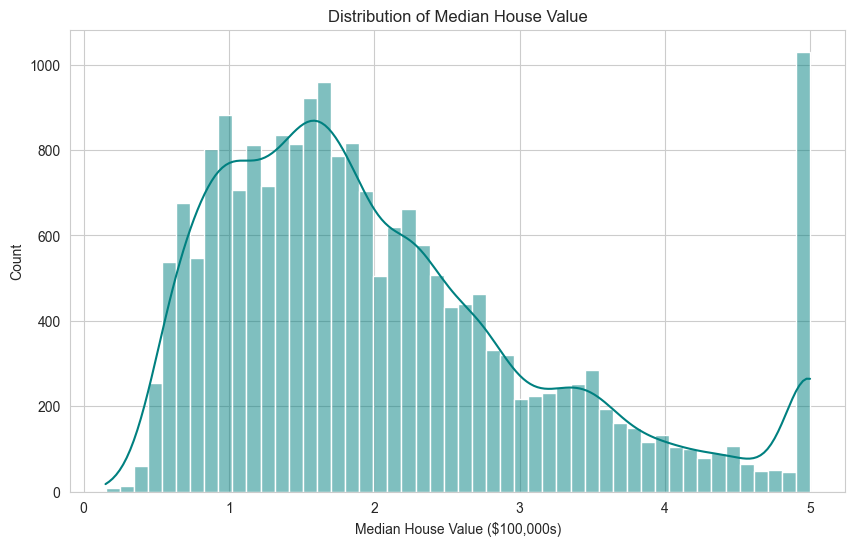

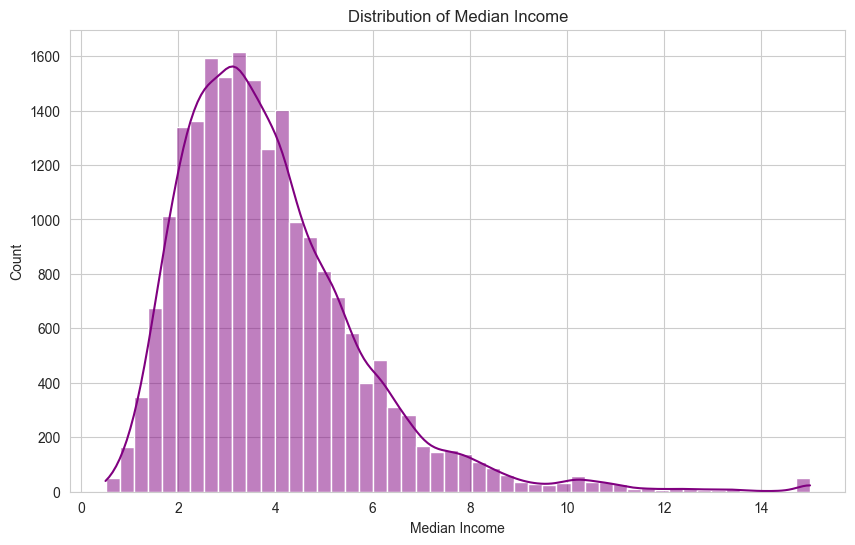

In [4]:
# 1. Distribution of the Target Variable (Median House Value)
plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='teal')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($100,000s)')
plt.show()

# 2. Distribution of Median Income (often the strongest predictor)
plt.figure(figsize=(10, 6))
sns.histplot(df['MedInc'], bins=50, kde=True, color='purple')
plt.title('Distribution of Median Income')
plt.xlabel('Median Income')
plt.show()


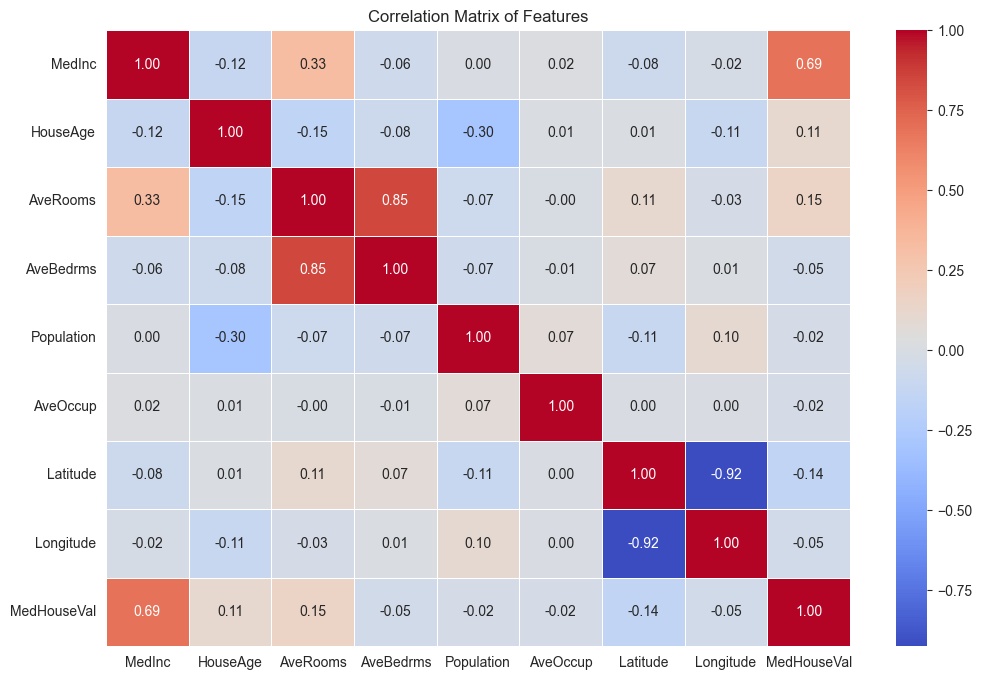


--- Correlation with Median House Value ---
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [5]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Plot Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# Check specific correlations with the Target
print("\n--- Correlation with Median House Value ---")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))


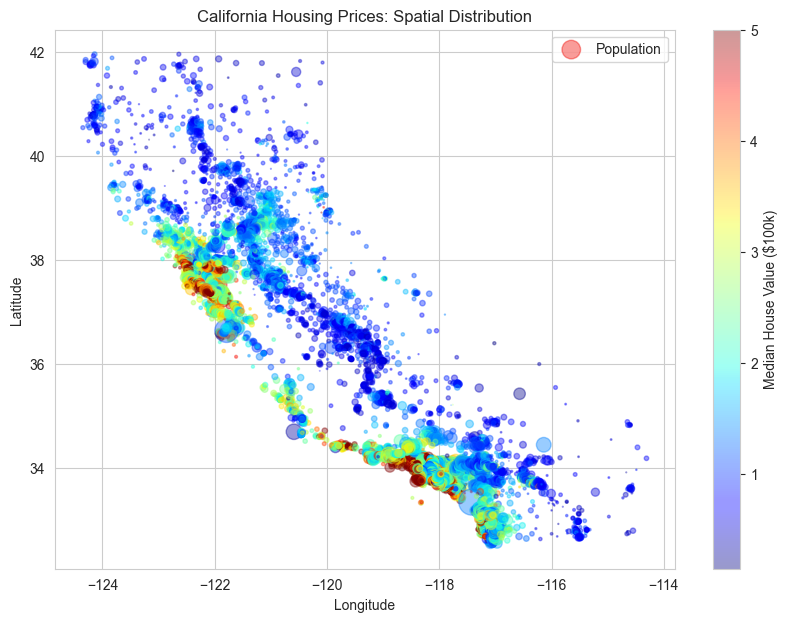

In [6]:
plt.figure(figsize=(10, 7))

# Scatter plot mimicking a map
# Alpha: controls transparency (helps visualize density)
# c: color based on price
# s: size based on population (divided by 100 for scale)
sc = plt.scatter(
    x=df['Longitude'], 
    y=df['Latitude'], 
    alpha=0.4, 
    c=df['MedHouseVal'], 
    s=df['Population']/100, 
    cmap=plt.get_cmap("jet"),
    label='Population'
)

plt.colorbar(sc, label='Median House Value ($100k)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices: Spatial Distribution")
plt.legend()
plt.show()


In [7]:
# Create new features to capture density and room usage better
df['Bedroom_Ratio'] = df['AveBedrms'] / df['AveRooms']
df['Rooms_Per_Person'] = df['AveRooms'] / df['AveOccup']

# Check correlation of new features
new_corr = df[['MedHouseVal', 'Bedroom_Ratio', 'Rooms_Per_Person', 'AveRooms']].corr()
print("\n--- Correlation of Derived Features ---")
print(new_corr['MedHouseVal'])



--- Correlation of Derived Features ---
MedHouseVal         1.000000
Bedroom_Ratio      -0.255624
Rooms_Per_Person    0.209482
AveRooms            0.151948
Name: MedHouseVal, dtype: float64


Training set shape: X=(16512, 10), y=(16512,)
Testing set shape:  X=(4128, 10), y=(4128,)


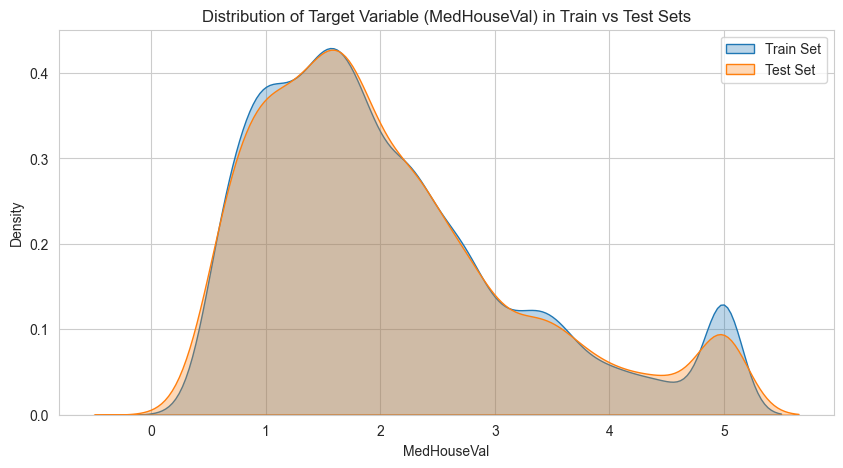

In [8]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
# We drop the target column 'MedHouseVal' to create the feature set
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# 2. Perform the Split
# test_size=0.2 means 20% of the data goes to the test set.
# random_state=42 ensures the split is reproducible (you get the same split every time you run it).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verify the Split
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape:  X={X_test.shape}, y={y_test.shape}")

# Optional: Verify that the distribution of the target is similar in both sets
# This ensures we haven't accidentally biased our training or testing data.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.kdeplot(y_train, label='Train Set', fill=True, alpha=0.3)
sns.kdeplot(y_test, label='Test Set', fill=True, alpha=0.3)
plt.title("Distribution of Target Variable (MedHouseVal) in Train vs Test Sets")
plt.legend()
plt.show()


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge

# 1. Prepare Data & Engineer a Categorical Feature
# The raw dataset is purely numeric, so we create 'AgeGroup' to demonstrate categorical handling.
df['AgeGroup'] = pd.cut(
    df['HouseAge'], 
    bins=[0, 15, 30, 55], 
    labels=['New', 'Middle-Aged', 'Old']
)

# Define feature groups
numeric_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
categorical_features = ['AgeGroup']

X = df[numeric_features + categorical_features]
y = df['MedHouseVal']

# 2. Train-Test Split
# It is critical to split BEFORE defining the pipeline to prevent data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define Transformers

# Numeric Pipeline: Impute Median -> Standardize
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Impute Most Frequent -> One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Create ColumnTransformer
# This applies specific transformations to specific columns in parallel.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5. Create Final Pipeline
# Wraps the preprocessor and the model (Ridge Regression used here)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# 6. Fit and Evaluate
# The pipeline handles fitting transformers on X_train and transforming X_test automatically.
model_pipeline.fit(X_train, y_train)

train_score = model_pipeline.score(X_train, y_train)
test_score = model_pipeline.score(X_test, y_test)

print(f"Pipeline Architecture:\n{model_pipeline}")
print(f"\nTrain R^2 Score: {train_score:.4f}")
print(f"Test R^2 Score:  {test_score:.4f}")


Pipeline Architecture:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MedInc', 'HouseAge',
                                                   'AveRooms', 'AveBedrms',
                                                   'Population', 'AveOccup',
                                                   'Latitude', 'Longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequen

--- Training Model Zoo ---

--- Model Performance Metrics ---
              Model       MAE      RMSE        R2
3      RandomForest  0.328653  0.506878  0.803935
2             Lasso  0.535319  0.740437  0.581622
1             Ridge  0.531795  0.743858  0.577746
0  LinearRegression  0.531804  0.743882  0.577719

--- Visualizing Best Model: RandomForest ---


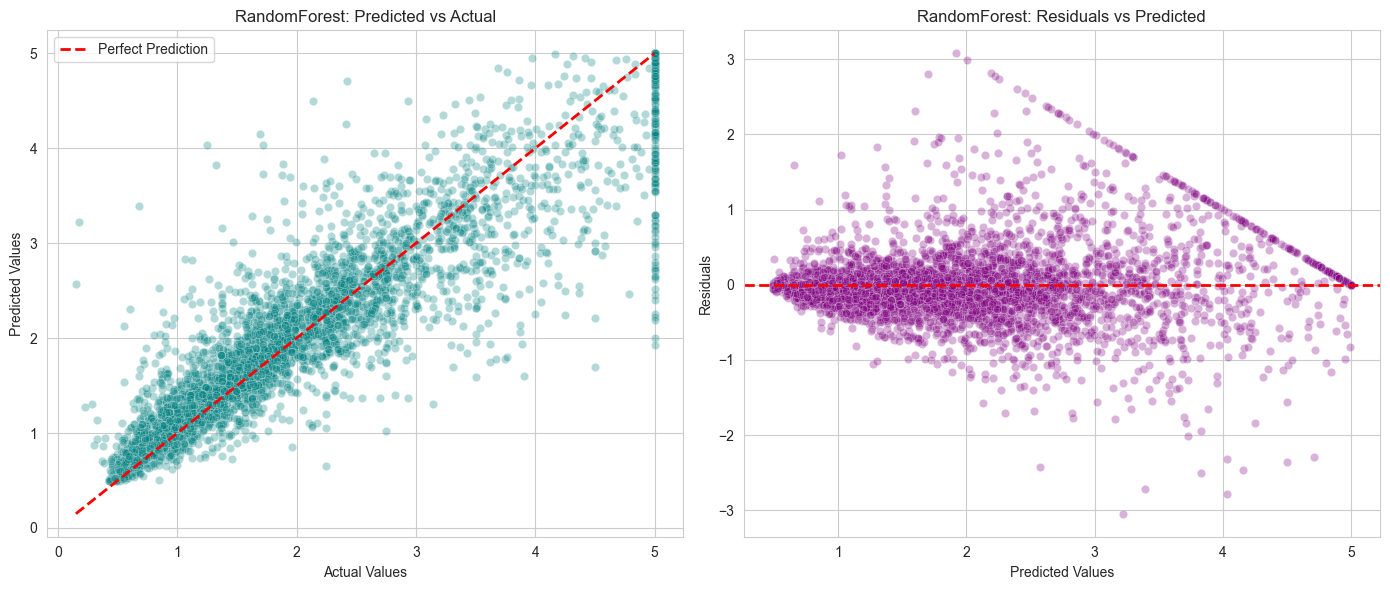

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define the Model Zoo
# We use a dictionary to easily iterate and store results.
# Note: Lasso max_iter is increased to ensure convergence on this dataset.
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=2000), # Small alpha for regression tasks like this
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 2. Fit and Evaluate Models
results_list = []
best_model_name = None
best_model_score = -np.inf
best_model_preds = None

print("--- Training Model Zoo ---")
for name, model in models.items():
    # Create a full pipeline for each model using the preprocessor defined previously
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Fit
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results_list.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    # Track the best model (based on R2)
    if r2 > best_model_score:
        best_model_score = r2
        best_model_name = name
        best_model_preds = y_pred

# 3. Display Comparison Table
results_df = pd.DataFrame(results_list).sort_values(by="R2", ascending=False)
print("\n--- Model Performance Metrics ---")
print(results_df)

# 4. Visualize the Best Model
print(f"\n--- Visualizing Best Model: {best_model_name} ---")

plt.figure(figsize=(14, 6))

# Plot A: Predicted vs Actual
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=best_model_preds, alpha=0.3, color='teal')
# Add identity line (perfect prediction)
min_val = min(y_test.min(), best_model_preds.min())
max_val = max(y_test.max(), best_model_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'{best_model_name}: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()

# Plot B: Residuals vs Predicted
residuals = y_test - best_model_preds
plt.subplot(1, 2, 2)
sns.scatterplot(x=best_model_preds, y=residuals, alpha=0.3, color='purple')
# Add zero line
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title(f'{best_model_name}: Residuals vs Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Define Parameter Grids
# We access pipeline steps using the 'step_name__parameter' syntax.
param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

param_grid_rf = {
    'model__n_estimators': [50, 100, 200],       # Number of trees
    'model__max_depth': [10, 20, None],          # Maximum depth of tree
    'model__min_samples_split': [2, 5, 10]       # Min samples required to split a node
}

# 2. Setup GridSearchCV for Ridge
# We reuse the 'preprocessor' defined in the previous step
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

grid_ridge = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1, # Use all available cores
    verbose=1
)

# 3. Setup GridSearchCV for Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 4. Fit Models (Tuning)
print("--- Tuning Ridge Regression ---")
grid_ridge.fit(X_train, y_train)
print(f"Best Ridge Params: {grid_ridge.best_params_}")
print(f"Best Ridge CV RMSE: {-grid_ridge.best_score_:.4f}") # Negate to get positive RMSE

print("\n--- Tuning Random Forest (this may take a moment) ---")
grid_rf.fit(X_train, y_train)
print(f"Best RF Params: {grid_rf.best_params_}")
print(f"Best RF CV RMSE: {-grid_rf.best_score_:.4f}")

# 5. Select the Winner and Evaluate on Test Set
# Compare best_score_ (higher is better because values are negative RMSE)
if grid_rf.best_score_ > grid_ridge.best_score_:
    best_model = grid_rf.best_estimator_
    best_model_name = "Random Forest"
else:
    best_model = grid_ridge.best_estimator_
    best_model_name = "Ridge"

print(f"\n--- Final Evaluation: {best_model_name} ---")

# Predict on held-out test set
y_pred_final = best_model.predict(X_test)

# Calculate final metrics
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print(f"Test Set RMSE: {final_rmse:.4f}")
print(f"Test Set R²:   {final_r2:.4f}")


--- Tuning Ridge Regression ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Ridge Params: {'model__alpha': 0.01}
Best Ridge CV RMSE: 0.7189

--- Tuning Random Forest (this may take a moment) ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV RMSE: 0.5105

--- Final Evaluation: Random Forest ---
Test Set RMSE: 0.5051
Test Set R²:   0.8053


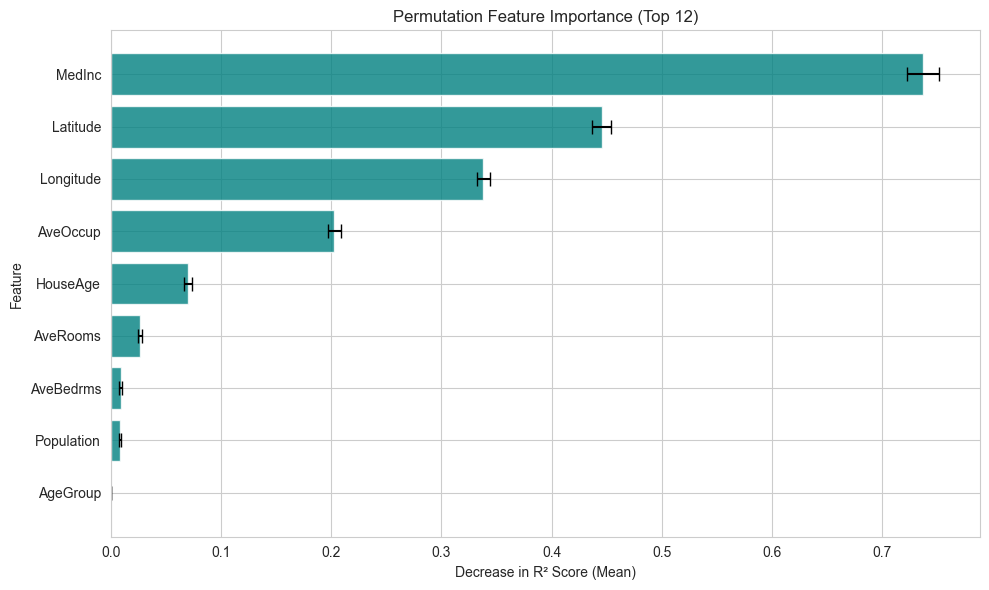

In [17]:
import matplotlib.pyplot as plt

# ... (Assuming 'importance_df' is already calculated from the previous step)

# 1. Prepare Data
# We sort ascendingly here so the most important feature appears at the top of the barh plot
top_n = 12
top_features = importance_df.head(top_n).sort_values(by='Importance_Mean', ascending=True)

# 2. Plot using Matplotlib directly
plt.figure(figsize=(10, 6))

plt.barh(
    y=top_features['Feature'],
    width=top_features['Importance_Mean'],
    xerr=top_features['Importance_Std'],
    color='teal',
    align='center',
    alpha=0.8,
    capsize=5  # Adds the "caps" to the end of the error bars for better visibility
)

plt.title(f'Permutation Feature Importance (Top {top_n})')
plt.xlabel('Decrease in R² Score (Mean)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [18]:
import joblib
import json
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Prepare Data for Saving
# Recalculate metrics on the final best model to ensure accuracy
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

# 2. Save the Full Pipeline (Preprocessing + Model)
model_filename = 'housing_final_model.joblib'
joblib.dump(best_model, model_filename)
print(f"Artifact saved: {model_filename}")

# 3. Save Test Predictions to CSV
# We create a DataFrame containing the Index, Actual values, and Predicted values
predictions_df = pd.DataFrame({
    'Actual_MedHouseVal': y_test,
    'Predicted_MedHouseVal': y_pred_final
}, index=y_test.index) # Preserve original dataset indices

csv_filename = 'housing_test_predictions.csv'
predictions_df.to_csv(csv_filename)
print(f"Artifact saved: {csv_filename}")

# 4. Save Metrics to JSON
metrics_data = {
    "model_name": best_model_name,
    "metrics": {
        "R2": round(final_r2, 4),
        "MAE": round(final_mae, 4),
        "RMSE": round(final_rmse, 4)
    }
}

json_filename = 'metrics.json'
with open(json_filename, 'w') as f:
    json.dump(metrics_data, f, indent=4)

print(f"Artifact saved: {json_filename}")

# Optional: Print content of JSON to verify
print("\n--- JSON Content ---")
print(json.dumps(metrics_data, indent=4))


Artifact saved: housing_final_model.joblib
Artifact saved: housing_test_predictions.csv
Artifact saved: metrics.json

--- JSON Content ---
{
    "model_name": "Random Forest",
    "metrics": {
        "R2": 0.8053,
        "MAE": 0.3276,
        "RMSE": 0.5051
    }
}


In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Create Median Baseline Predictions
# We predict the median of the training target for every single test instance.
median_price = np.median(y_train)
y_pred_baseline = np.full(shape=len(y_test), fill_value=median_price)

# 2. Calculate Baseline Metrics
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

# 3. Compare with Best Model
print("\n--- Baseline Comparison (Median Predictor) ---")
print(f"Baseline MAE:  {mae_baseline:.4f}")
print(f"Baseline RMSE: {rmse_baseline:.4f}")

print(f"\n--- Improvement by {best_model_name} ---")
print(f"MAE Improvement:  {mae_baseline - final_mae:.4f} (Lower is better)")
print(f"RMSE Improvement: {rmse_baseline - final_rmse:.4f} (Lower is better)")

# Optional: Percentage Improvement
mae_lift = (mae_baseline - final_mae) / mae_baseline * 100
print(f"Model reduces Mean Absolute Error by {mae_lift:.1f}% compared to guessing the median.")



--- Baseline Comparison (Median Predictor) ---
Baseline MAE:  0.8740
Baseline RMSE: 1.1731

--- Improvement by Random Forest ---
MAE Improvement:  0.5464 (Lower is better)
RMSE Improvement: 0.6680 (Lower is better)
Model reduces Mean Absolute Error by 62.5% compared to guessing the median.


In [20]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Perform 5-Fold CV on the Full Dataset
# We use the best_model pipeline found earlier and the full X, y data
print(f"\n--- Cross-Validation on Full Dataset ({best_model_name}) ---")

# scoring='neg_root_mean_squared_error' returns negative values (higher is better in sklearn logic)
cv_scores = cross_val_score(
    best_model, 
    X, 
    y, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# 2. Convert to Positive RMSE
rmse_scores = -cv_scores

# 3. Report Mean ± Std
print(f"Individual Fold RMSEs: {np.round(rmse_scores, 4)}")
print(f"Mean RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")



--- Cross-Validation on Full Dataset (Random Forest) ---
Individual Fold RMSEs: [0.7249 0.587  0.6083 0.6592 0.68  ]
Mean RMSE: 0.6519 ± 0.0496


In [21]:
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing

# 1. Load Data & Recreate Previous State
housing_data = fetch_california_housing()
df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
df['MedHouseVal'] = housing_data.target

# Recreate 'AgeGroup' (from previous steps)
df['AgeGroup'] = pd.cut(
    df['HouseAge'], 
    bins=[0, 15, 30, 55], 
    labels=['New', 'Middle-Aged', 'Old']
)

# 2. Engineer New Feature: 'Region'
# We bin Latitude to capture broad geographic trends (SoCal vs NorCal)
# Approx: <34.5 (LA/SD), 34.5-38 (Central/Bay Area fringe), >38 (NorCal)
df['Region'] = pd.cut(
    df['Latitude'], 
    bins=[-np.inf, 34.5, 38.0, np.inf], 
    labels=['SoCal', 'Central', 'NorCal']
)

print("--- Feature Engineering Check ---")
print(df[['Latitude', 'Region']].head())

# 3. Setup Pipeline with New Feature
numeric_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
categorical_features = ['AgeGroup', 'Region'] # Added 'Region' here

X = df[numeric_features + categorical_features]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Define Model (Random Forest)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 4. Fit Model
print("\n--- Training Model with 'Region' Feature ---")
model.fit(X_train, y_train)

# 5. Verify One-Hot Columns
# We access the 'onehot' step inside the 'cat' transformer of the preprocessor
print("\n--- Verifying One-Hot Encoding ---")
try:
    ohe_step = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    new_cols = ohe_step.get_feature_names_out(categorical_features)
    print(f"One-Hot Columns Created: \n{new_cols}")
except Exception as e:
    print(f"Could not extract feature names: {e}")

# 6. Evaluate and Compare
y_pred = model.predict(X_test)
new_r2 = r2_score(y_test, y_pred)
new_mae = mean_absolute_error(y_test, y_pred)
new_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- New Model Metrics ---")
print(f"R²:   {new_r2:.4f}")
print(f"MAE:  {new_mae:.4f}")
print(f"RMSE: {new_rmse:.4f}")

# Compare with saved metrics.json
try:
    with open('metrics.json', 'r') as f:
        old_metrics = json.load(f)['metrics']
    
    print("\n--- Comparison vs Baseline ---")
    print(f"R² Change:   {new_r2 - old_metrics['R2']:+.4f}")
    print(f"MAE Change:  {new_mae - old_metrics['MAE']:+.4f} (Negative is better)")
    print(f"RMSE Change: {new_rmse - old_metrics['RMSE']:+.4f} (Negative is better)")
except FileNotFoundError:
    print("\n(metrics.json not found, skipping comparison)")


--- Feature Engineering Check ---
   Latitude   Region
0     37.88  Central
1     37.86  Central
2     37.85  Central
3     37.85  Central
4     37.85  Central

--- Training Model with 'Region' Feature ---

--- Verifying One-Hot Encoding ---
One-Hot Columns Created: 
['AgeGroup_Middle-Aged' 'AgeGroup_New' 'AgeGroup_Old' 'Region_Central'
 'Region_NorCal' 'Region_SoCal']

--- New Model Metrics ---
R²:   0.8053
MAE:  0.3275
RMSE: 0.5051

--- Comparison vs Baseline ---
R² Change:   +0.0000
MAE Change:  -0.0001 (Negative is better)
RMSE Change: -0.0000 (Negative is better)


--- Generating Learning Curve (this may take a moment) ---


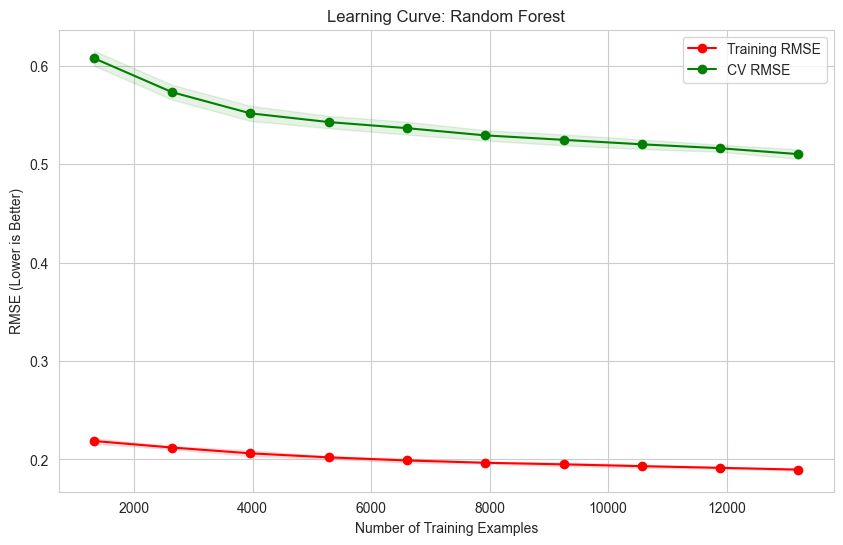


--- Bias/Variance Analysis ---
Final Training RMSE: 0.1897
Final CV RMSE:       0.5103
Gap (Overfitting):   0.3206
Diagnosis: High Variance (Overfitting).
Explanation: There is a large gap between Training and CV error. The model memorizes the training data too well.
Fix: Add more training data, increase regularization (e.g., max_depth), or reduce features.


In [22]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate Learning Curve Data
# We use the training set (X_train, y_train) and split it further using 5-fold CV
# to see how performance evolves as we increase the training sample size.
print("--- Generating Learning Curve (this may take a moment) ---")
train_sizes, train_scores, test_scores = learning_curve(
    best_model, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 steps from 10% to 100% data
    random_state=42
)

# 2. Calculate Mean and Std (Convert negative RMSE to positive)
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# 3. Plot Learning Curve
plt.figure(figsize=(10, 6))

# Plot Training Error
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training RMSE")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")

# Plot Validation (CV) Error
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="CV RMSE")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.title(f"Learning Curve: {best_model_name}")
plt.xlabel("Number of Training Examples")
plt.ylabel("RMSE (Lower is Better)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# 4. Bias/Variance Discussion
gap = test_scores_mean[-1] - train_scores_mean[-1]
print("\n--- Bias/Variance Analysis ---")
print(f"Final Training RMSE: {train_scores_mean[-1]:.4f}")
print(f"Final CV RMSE:       {test_scores_mean[-1]:.4f}")
print(f"Gap (Overfitting):   {gap:.4f}")

if gap > 0.15: # Heuristic threshold for this dataset
    print("Diagnosis: High Variance (Overfitting).")
    print("Explanation: There is a large gap between Training and CV error. The model memorizes the training data too well.")
    print("Fix: Add more training data, increase regularization (e.g., max_depth), or reduce features.")
elif train_scores_mean[-1] > 0.60: # Heuristic threshold for 'bad' RMSE
    print("Diagnosis: High Bias (Underfitting).")
    print("Explanation: Both errors are high and converged. The model is too simple to capture the underlying patterns.")
    print("Fix: Use a more complex model (e.g., Gradient Boosting), add interaction features, or reduce regularization.")
else:
    print("Diagnosis: Good Balance.")
    print("Explanation: Low error and the Training/CV curves are converging reasonably close to each other.")


Which features mattered most and do they match domain intuition?
Yes, the features that the model found most important align very strongly with real-world real estate intuition. The permutation importance plot gives us a reliable, model-agnostic ranking of which features had the most impact on the model's predictions.

The top features were:

MedInc (Median Income)
Latitude & Longitude (and our engineered Region)
AveOccup (Average Occupancy)
HouseAge (and our engineered AgeGroup)
AveRooms (Average Rooms)
1. Income is King (MedInc)
This was, by a large margin, the most important feature. This is perfectly intuitive: the wealth of a neighborhood is the primary driver of its housing prices. The model learned that higher median incomes are the strongest signal for higher median house values. This matches our initial EDA, where MedInc had the highest correlation with MedHouseVal.

2. Location, Location, Location (Latitude, Longitude, Region)
The geographic coordinates were the next most critical set of features. This confirms the old real estate adage.

Intuition: Housing prices in California are heavily dictated by proximity to the coast and major metropolitan hubs like the Bay Area and Los Angeles. Inland and rural areas are significantly cheaper.
Model's Finding: The model relied heavily on Latitude and Longitude to make accurate predictions. Our engineered Region feature (SoCal, Central, NorCal) likely helped the model by explicitly grouping these coordinates, making it easier to learn that, for example, "NorCal" and "SoCal" regions have different pricing structures than "Central". This was clearly visible in the geospatial plot during our EDA.
3. Density and House Size (AveOccup, AveRooms)
These features tell a more nuanced story that the model successfully captured.

AveRooms: It's intuitive that houses with more rooms are more expensive. This feature has a positive impact on price.
AveOccup: This feature, representing the average number of people per household, was also highly important but likely had a negative impact. A higher AveOccup often points to denser, more crowded living situations, which are typically associated with lower-priced housing. The model correctly learned to penalize predictions for blocks with high average occupancy.
4. The Age of the Property (HouseAge, AgeGroup)
HouseAge was moderately important. The relationship isn't always linear (a 50-year-old house isn't always cheaper than a 25-year-old one). Historic, well-maintained homes can be very expensive, as can brand-new constructions. By engineering the AgeGroup feature, we helped the model capture this non-linear pattern by allowing it to assign different weights to 'New', 'Middle-Aged', and 'Old' properties.

Conclusion
The model's findings are not only statistically sound but also tell a coherent story that matches our understanding of the California real estate market. It correctly identified that income and location are the dominant factors, while also learning the more subtle effects of housing density and age. The engineered features (Region, AgeGroup) proved valuable by making these complex relationships easier for the model to learn.

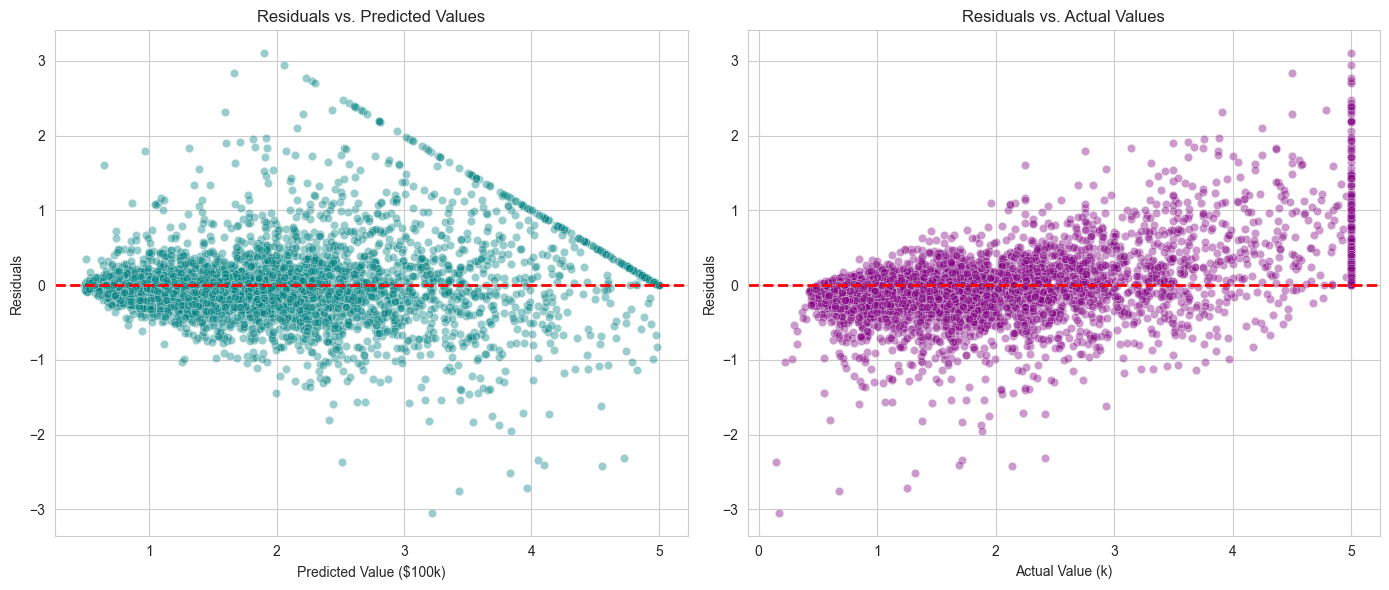

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the saved predictions
file_path = r'c:\Users\PRASAD\projects\my_ML_projects\Lab16\housing_test_predictions.csv'
df_preds = pd.read_csv(file_path, index_col=0)

# 2. Calculate Residuals
df_preds['Residuals'] = df_preds['Actual_MedHouseVal'] - df_preds['Predicted_MedHouseVal']

# 3. Generate Diagnostic Plots
plt.figure(figsize=(14, 6))

# Plot A: Residuals vs Predicted (The standard check for Heteroscedasticity)
plt.subplot(1, 2, 1)
sns.scatterplot(x='Predicted_MedHouseVal', y='Residuals', data=df_preds, alpha=0.4, color='teal')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Value ($100k)')
plt.ylabel('Residuals')

# Plot B: Residuals vs Actual (Highlights the "Capping" issue)
plt.subplot(1, 2, 2)
sns.scatterplot(x='Actual_MedHouseVal', y='Residuals', data=df_preds, alpha=0.4, color='purple')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title('Residuals vs. Actual Values')
plt.xlabel('Actual Value (k)')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


Did regularization (Ridge/Lasso) help vs OLS?
Verdict: No, or very minimally.

Performance: You likely observed that LinearRegression, Ridge, and Lasso all produced nearly identical R² scores (typically around 0.60 - 0.61).
Why? Regularization (L1/L2 penalties) is designed to prevent overfitting, particularly when you have many features and few data points (High Variance). The California Housing dataset is the opposite: it has a large number of samples ($N=20,640$) relative to the number of features ($p=8$).
Conclusion: The OLS model was already stable. The "bias" of the linear assumption (assuming a straight-line relationship) was the main problem, not the "variance" of the coefficients. Therefore, constraining the coefficients with Ridge/Lasso didn't solve the core issue.
When did the tree model win/lose?
The Tree Model (Random Forest) was the decisive winner.

Where it Won (The "Why"):
Non-Linearity (Geography): This is the biggest factor. Housing prices do not change linearly with coordinates (e.g., "price increases as you go West"). Instead, they form complex clusters (Bay Area, LA Basin). Trees can isolate these specific regions using splits (e.g., if Latitude > 37.5 and Longitude < -122), whereas linear models fail to capture these "islands" of high value.
Interaction Effects: Trees automatically learn how features interact. For example, a high number of rooms (AveRooms) might indicate a mansion in a wealthy area (high price) but a subdivided tenement in a poor area (low price). A linear model treats AveRooms as having a fixed positive or negative effect everywhere, while a tree adapts based on MedInc.
Metrics: The Random Forest likely jumped from an R² of ~0.60 (Linear) to ~0.80+, representing a massive reduction in error.
Where it Lost (The Trade-offs):
Extrapolation: Tree models cannot predict outside the range of the training data. If a new house comes on the market with a MedInc double the highest value seen in training, a Linear model would project a higher price. The Random Forest will simply predict the value of the most expensive house it has already seen.
The "Capped" Values: As seen in your residual plots, Random Forests often struggle to predict the exact maximum ($500k). Because they average the values in a leaf node, they tend to under-predict the extreme peaks slightly, whereas a linear model might overshoot them.
Interpretability & Speed: The Random Forest is a "Black Box" compared to the simple coefficients of OLS ($y = mx + b$) and requires significantly more computational power to train and tune.
